In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Custom CNN
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test,y_test)
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test,y_test)
print("Accuracy:", test_acc)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 71s 0us/step 


C:\Users\Ravi Kumar\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.4527 - loss: 1.5214 - val_accuracy: 0.5553 - val_loss: 1.2666
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5930 - loss: 1.1540 - val_accuracy: 0.6202 - val_loss: 1.0860
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6462 - loss: 1.0128 - val_accuracy: 0.6346 - val_loss: 1.0352
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6753 - loss: 0.9339 - val_accuracy: 0.6545 - val_loss: 0.9881
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7005 - loss: 0.8645 - val_accuracy: 0.6805 - val_loss: 0.9289
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7194 - loss: 0.8129 - val_accuracy: 0.6699 - val_loss: 0.9684
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7336 - loss: 0.7681 - val_accuracy: 0.6850 - val_loss: 0.9166
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7491 - loss: 

In [2]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  
[[779  12  33  11  20  12  10  14  69  40]
 [ 27 815   6   2   5   7   8   8  33  89]
 [ 79   9 539  38  91  93  71  50  15  15]
 [ 24  13  62 377 106 257  77  49  16  19]
 [ 25   4  61  38 679  50  52  76  12   3]
 [ 12   5  34  97  54 713  17  48   6  14]
 [  9   3  46  44  56  36 784   8   5   9]
 [ 13   5  26  18  52  68   8 786   2  22]
 [ 71  22  16  12   9  13   4   5 813  35]
 [ 29  70   4  10  10  11   5  21  35 805]]
              precision    recall  f1-score   support

           0       0.73      0.78      0.75      1000
           1       0.85      0.81      0.83      1000
           2       0.65      0.54      0.59      1000
           3       0.58      0.38      0.46      1000
           4       0.63      0.68      0.65      1000
           5       0.57      0.71      0.63      1000
           6       0.76      0.78      0.77      1000
           7       0.74      0.79      0.76      1000
           8       0.81      0.81      

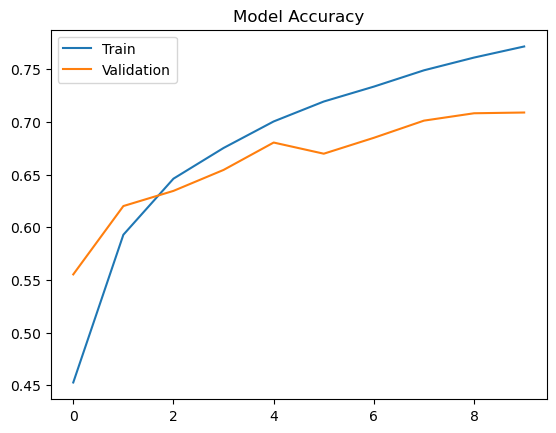

In [3]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train','Validation'])
plt.show()